In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Clean_Text_Glassdoor - cleaned_glassdoor_reviews.csv")
df

,review_id,rating_date,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,rating_diversity_inclusion,rating_overall,rating_work_life,career_opportunities_rating,employee_location,employee_job_title,advice_to_management,review_pros,review_cons,rating_senior_leadership,rating_compensation_benefits
0,1,2025-06-03T00:00:00.000Z,0,REGULAR,Current employee,NAN,NAN,NAN,0.0,0.0,3,0.0,NaN,"Richmond, VA",Warehouse Fulfillment Associate,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,0.0,0.0
1,2,2025-05-29T00:00:00.000Z,1,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,5.0,4,3.0,NaN,"Brampton, ON",Warehouse Associate,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...,3.0,5.0
2,3,2025-05-28T00:00:00.000Z,1,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,5.0,5,5.0,NaN,"Bolton, ON",Warehouse Associate,NaN,help grow good pay,limited opportunities advancementno clear path...,5.0,5.0
3,4,2025-05-26T00:00:00.000Z,2,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,2.0,3,2.0,NaN,"Swedesboro, NJ",Employee,NaN,plenty work meet new people,tough body labor intensive,2.0,2.0
4,5,2025-05-23T00:00:00.000Z,0,REGULAR,Current employee,NAN,NAN,NAN,0.0,0.0,4,0.0,NaN,"Whitby, ON",Fulfillment Associate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,137,2026-01-31T00:00:00.000Z,<1,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,5,NaN,NaN,"Hamilton, ON",Associate,NaN,good pay ot,fast pace work long hours,NaN,NaN
129,138,2026-01-29T00:00:00.000Z,3+,REGULAR,Current Employee,POSITIVE,NEUTRAL,POSITIVE,2.0,5.0,4,3.0,4.0,"Charlotte, NC",Associate,get closer eith people bellow,good pay opportunities growth,long hours mandatory ot peak seasons,4.0,5.0
130,139,2026-01-28T00:00:00.000Z,NaN,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,5,NaN,NaN,NaN,Area Manager,NaN,pay amazing balanced,work load demanding,NaN,NaN
131,140,2026-01-28T00:00:00.000Z,NaN,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,4,NaN,NaN,"Sacramento, CA",Associate,NaN,work straightforward easy pick,shifts hours change depending demand making ha...,NaN,NaN


In [ ]:
df['summary'] = df['review_pros'].fillna('') + ' ' + df['review_cons'].fillna('')
df['sentiment_polarity'] = df['summary'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment_subjectivity'] = df['summary'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df

,review_id,rating_date,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,rating_diversity_inclusion,...,employee_location,employee_job_title,advice_to_management,review_pros,review_cons,rating_senior_leadership,rating_compensation_benefits,summary,sentiment_polarity,sentiment_subjectivity
0,1,2025-06-03T00:00:00.000Z,0,REGULAR,Current employee,NAN,NAN,NAN,0.0,0.0,...,"Richmond, VA",Warehouse Fulfillment Associate,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,0.0,0.0,interactive leave take whenever long time easy...,-0.123333,0.495238
1,2,2025-05-29T00:00:00.000Z,1,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,5.0,...,"Brampton, ON",Warehouse Associate,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...,3.0,5.0,good easy work enviorment sticks rules complet...,0.566667,0.716667
2,3,2025-05-28T00:00:00.000Z,1,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,5.0,...,"Bolton, ON",Warehouse Associate,NaN,help grow good pay,limited opportunities advancementno clear path...,5.0,5.0,help grow good pay limited opportunities advan...,0.242857,0.375397
3,4,2025-05-26T00:00:00.000Z,2,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,2.0,...,"Swedesboro, NJ",Employee,NaN,plenty work meet new people,tough body labor intensive,2.0,2.0,plenty work meet new people tough body labor i...,-0.126263,0.643939
4,5,2025-05-23T00:00:00.000Z,0,REGULAR,Current employee,NAN,NAN,NAN,0.0,0.0,...,"Whitby, ON",Fulfillment Associate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly,0.0,0.0,good holiday pay additional benefits permanent...,0.400000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,137,2026-01-31T00:00:00.000Z,<1,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,...,"Hamilton, ON",Associate,NaN,good pay ot,fast pace work long hours,NaN,NaN,good pay ot fast pace work long hours,0.283333,0.533333
129,138,2026-01-29T00:00:00.000Z,3+,REGULAR,Current Employee,POSITIVE,NEUTRAL,POSITIVE,2.0,5.0,...,"Charlotte, NC",Associate,get closer eith people bellow,good pay opportunities growth,long hours mandatory ot peak seasons,4.0,5.0,good pay opportunities growth long hours manda...,0.325000,0.500000
130,139,2026-01-28T00:00:00.000Z,NaN,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,...,NaN,Area Manager,NaN,pay amazing balanced,work load demanding,NaN,NaN,pay amazing balanced work load demanding,0.600000,0.900000
131,140,2026-01-28T00:00:00.000Z,NaN,REGULAR,Former Employee,NAN,NAN,NAN,NaN,NaN,...,"Sacramento, CA",Associate,NaN,work straightforward easy pick,shifts hours change depending demand making ha...,NaN,NaN,work straightforward easy pick shifts hours ch...,0.172222,0.583333


In [ ]:
def label_sentiment(score):
  if score > .1:
    return 'positive'
  elif score < .1:
    return 'negative'
  else:
    return 'neutral'

df['sentiment_label'] = df['sentiment_polarity'].apply(label_sentiment)

In [ ]:
df.head()

,review_id,rating_date,employee_length,employee_status,employee_type,flags_business_outlook,flags_ceo_approval,flags_recommend_frend,rating_culture_values,rating_diversity_inclusion,...,employee_job_title,advice_to_management,review_pros,review_cons,rating_senior_leadership,rating_compensation_benefits,summary,sentiment_polarity,sentiment_subjectivity,sentiment_label
0,1,2025-06-03T00:00:00.000Z,0,REGULAR,Current employee,NAN,NAN,NAN,0.0,0.0,...,Warehouse Fulfillment Associate,don’t micro manage,interactive leave take whenever long time easy...,inhumane draining physically amp mentally,0.0,0.0,interactive leave take whenever long time easy...,-0.123333,0.495238,negative
1,2,2025-05-29T00:00:00.000Z,1,CONTRACT,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,5.0,...,Warehouse Associate,remove attitude manager warehouse,good easy work enviorment,sticks rules completing targets otherwise get ...,3.0,5.0,good easy work enviorment sticks rules complet...,0.566667,0.716667,positive
2,3,2025-05-28T00:00:00.000Z,1,REGULAR,"Current employee, less than 1 year",POSITIVE,APPROVE,POSITIVE,5.0,5.0,...,Warehouse Associate,NaN,help grow good pay,limited opportunities advancementno clear path...,5.0,5.0,help grow good pay limited opportunities advan...,0.242857,0.375397,positive
3,4,2025-05-26T00:00:00.000Z,2,PART_TIME,Current employees,POSITIVE,APPROVE,POSITIVE,2.0,2.0,...,Employee,NaN,plenty work meet new people,tough body labor intensive,2.0,2.0,plenty work meet new people tough body labor i...,-0.126263,0.643939,negative
4,5,2025-05-23T00:00:00.000Z,0,REGULAR,Current employee,NAN,NAN,NAN,0.0,0.0,...,Fulfillment Associate,NaN,good holiday pay additional benefits permanent...,hiring permanent employees directly,0.0,0.0,good holiday pay additional benefits permanent...,0.400000,0.500000,positive


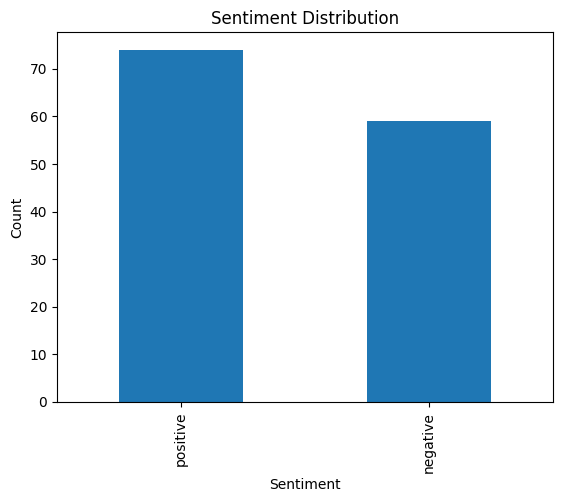

In [ ]:
df['sentiment_label'].value_counts().plot(kind='bar', title="Sentiment Distribution")
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

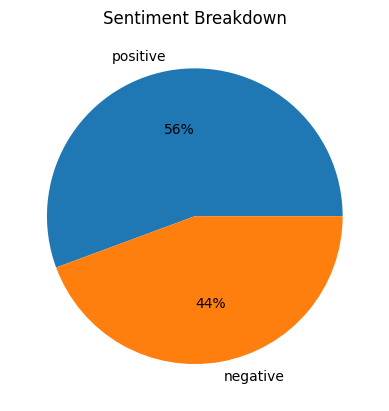

In [ ]:
df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

In [ ]:
df.to_csv('Sentiment_Analysis_Glassdoor.csv')